# CASAS Aruba Smart Home Dataset - Dementia Detection
## Stage 1: Understanding & Loading CASAS Data

**Important:** This project uses the **CASAS Aruba** dataset from https://casas.wsu.edu/datasets/
- Single elderly resident
- Months of longitudinal sensor data
- Labeled activities (Sleep, Meal_Preparation, Eating, etc.)
- Best suited for dementia pattern detection

**Data Format:**
```
2010-11-04 00:03:50.209589  M009  ON   Sleep_Out_of_Bed
2010-11-04 00:03:53.121010  M009  OFF
2010-11-04 00:04:01.209589  M010  ON
```
Each row: `timestamp | sensor_id | state | activity_label (optional)`

In [7]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
import os

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


## Stage 1: Load CASAS Aruba Dataset

Loading the pre-processed CSV format directly from Kaggle provides clean, structured data ready for analysis.

In [11]:
import pandas as pd
import numpy as np
import os

DATA_DIR = '/kaggle/input/datasets/ashley6009/casas-smart-home-dataset/data'

df = pd.read_csv(
    os.path.join(DATA_DIR, 'aruba.csv'),
    header=None,
    names=['date', 'time', 'sensor', 'state']
)

# ── Combine date + time into single timestamp ─────────────────────────────
df['timestamp'] = pd.to_datetime(
    df['date'].astype(str) + ' ' + df['time'].astype(str),
    format='mixed'
)
df = df.drop(columns=['date', 'time'])
df = df[['timestamp', 'sensor', 'state']]

# ── Clean whitespace ──────────────────────────────────────────────────────
df['sensor'] = df['sensor'].astype(str).str.strip()
df['state']  = df['state'].astype(str).str.strip()

df = df.sort_values('timestamp').reset_index(drop=True)

print("✓ Loaded successfully!")
print(f"  Rows: {df.shape[0]:,}")
print(f"  Date range: {df['timestamp'].min()} → {df['timestamp'].max()}")
print(f"  Unique sensors: {df['sensor'].nunique()}")
print(f"  Sensor list: {sorted(df['sensor'].unique().tolist())}")
print(f"  States: {df['state'].unique().tolist()}")
print("\nFirst 10 rows:")
print(df.head(10).to_string())

✓ Loaded successfully!
  Rows: 1,602,821
  Date range: 2010-11-04 00:03:50.209589 → 2011-06-11 23:20:35.722380
  Unique sensors: 10
  Sensor list: ['Bathroom', 'Bedroom', 'DiningRoom', 'GuestRoom', 'Kitchen', 'LivingRoom', 'LoungeChair', 'OtherRoom', 'OutsideDoor', 'WorkArea']
  States: ['ON', 'OFF', 'OPEN', 'CLOSE']

First 10 rows:
                   timestamp   sensor state
0 2010-11-04 00:03:50.209589  Bedroom    ON
1 2010-11-04 00:03:57.399391  Bedroom   OFF
2 2010-11-04 02:32:33.351906  Bedroom    ON
3 2010-11-04 02:32:38.895958  Bedroom   OFF
4 2010-11-04 03:42:21.823650  Bedroom    ON
5 2010-11-04 03:42:25.939730  Bedroom   OFF
6 2010-11-04 03:49:52.412755  Bedroom    ON
7 2010-11-04 03:49:57.473649  Bedroom   OFF
8 2010-11-04 04:14:32.835757  Bedroom    ON
9 2010-11-04 04:14:33.203704  Bedroom    ON


## Explore the Data Structure

In [14]:
# ── Stage 2: Feature Engineering ─────────────────────────────────────────
# Using your exact sensor names from aruba.csv

def engineer_daily_features(df):
    
    df = df.copy()
    df['date']    = df['timestamp'].dt.date
    df['hour']    = df['timestamp'].dt.hour
    df['weekday'] = df['timestamp'].dt.weekday  # 0=Mon, 6=Sun

    # ── Your exact sensor mappings ────────────────────────────────────────
    KITCHEN_SENSORS  = {'Kitchen'}
    BEDROOM_SENSORS  = {'Bedroom', 'GuestRoom'}
    BATHROOM_SENSORS = {'Bathroom'}
    DOOR_SENSORS     = {'OutsideDoor'}
    LIVING_SENSORS   = {'LivingRoom', 'LoungeChair', 'DiningRoom'}
    ACTIVE_SENSORS   = {'Kitchen', 'Bathroom', 'LivingRoom',
                        'DiningRoom', 'WorkArea', 'OtherRoom'}

    daily_features = []

    for date, day_df in df.groupby('date'):

        # Active events = sensor turned ON or door OPEN
        active = day_df[day_df['state'].isin(['ON', 'OPEN'])]

        # ── Room visit counts ─────────────────────────────────────────────
        kitchen_visits  = active['sensor'].isin(KITCHEN_SENSORS).sum()
        bedroom_visits  = active['sensor'].isin(BEDROOM_SENSORS).sum()
        bathroom_visits = active['sensor'].isin(BATHROOM_SENSORS).sum()
        door_opens      = active['sensor'].isin(DOOR_SENSORS).sum()
        living_visits   = active['sensor'].isin(LIVING_SENSORS).sum()
        total_events    = len(active)

        # ── Wake / sleep time proxies ─────────────────────────────────────
        if len(active):
            first_hour   = active['hour'].min()
            last_hour    = active['hour'].max()
            active_span  = last_hour - first_hour
        else:
            first_hour = last_hour = active_span = 0

        # ── Inactive hours (sedentary drift indicator) ────────────────────
        hours_with_events = day_df.groupby('hour').size()
        inactive_hours    = 24 - len(hours_with_events)

        # ── Nighttime activity (Sundowning indicator) ─────────────────────
        # Night = 10pm to 6am
        night_mask        = (day_df['hour'] >= 22) | (day_df['hour'] <= 6)
        night_df          = day_df[night_mask & day_df['state'].isin(['ON', 'OPEN'])]
        night_events      = len(night_df)
        night_door_opens  = night_df['sensor'].isin(DOOR_SENSORS).sum()
        night_bedroom     = night_df['sensor'].isin(BEDROOM_SENSORS).sum()
        night_kitchen     = night_df['sensor'].isin(KITCHEN_SENSORS).sum()

        # ── Meal detection ────────────────────────────────────────────────
        # Proxy: kitchen activity during typical meal windows
        breakfast = active[active['hour'].between(6, 10)]['sensor'].isin(KITCHEN_SENSORS).sum()
        lunch     = active[active['hour'].between(11, 14)]['sensor'].isin(KITCHEN_SENSORS).sum()
        dinner    = active[active['hour'].between(17, 21)]['sensor'].isin(KITCHEN_SENSORS).sum()
        meals_detected = (breakfast > 0) + (lunch > 0) + (dinner > 0)

        # ── Bathroom frequency (hygiene routine indicator) ────────────────
        morning_bathroom = day_df[
            day_df['hour'].between(6, 10) &
            day_df['sensor'].isin(BATHROOM_SENSORS) &
            day_df['state'].isin(['ON'])
        ]
        morning_bathroom_visits = len(morning_bathroom)

        # ── Door activity ─────────────────────────────────────────────────
        daytime_door = active[
            active['hour'].between(7, 21) &
            active['sensor'].isin(DOOR_SENSORS)
        ]
        daytime_door_opens = len(daytime_door)

        # ── Risk labels (targets for your classifier) ─────────────────────
        sedentary_risk   = 1 if inactive_hours >= 18 else 0
        night_wander     = 1 if night_door_opens > 0 else 0
        meal_skip        = 1 if meals_detected < 2 else 0
        kitchen_risk     = 1 if (kitchen_visits > 0 and meals_detected == 0) else 0

        daily_features.append({
            'date':                  date,
            'weekday':               day_df['weekday'].iloc[0],

            # Core activity counts
            'total_events':          total_events,
            'kitchen_visits':        kitchen_visits,
            'bedroom_visits':        bedroom_visits,
            'bathroom_visits':       bathroom_visits,
            'living_visits':         living_visits,
            'door_opens':            door_opens,

            # Temporal routine
            'first_active_hour':     first_hour,
            'last_active_hour':      last_hour,
            'active_span_hrs':       active_span,
            'inactive_hours':        inactive_hours,

            # Meal routine
            'breakfast_activity':    int(breakfast > 0),
            'lunch_activity':        int(lunch > 0),
            'dinner_activity':       int(dinner > 0),
            'meals_detected':        meals_detected,

            # Dementia-specific signals
            'night_events':          night_events,
            'night_door_opens':      night_door_opens,
            'night_kitchen':         night_kitchen,
            'morning_bathroom':      morning_bathroom_visits,
            'daytime_door_opens':    daytime_door_opens,

            # Risk labels — these are your ML targets
            'sedentary_risk':        sedentary_risk,
            'night_wander_risk':     night_wander,
            'meal_skip_risk':        meal_skip,
            'kitchen_safety_risk':   kitchen_risk,
        })

    return pd.DataFrame(daily_features)


print("Engineering daily features... (may take 30–60 seconds)")
features_df = engineer_daily_features(df)

print(f"\n✓ Feature engineering complete!")
print(f"  Days in dataset: {len(features_df)}")
print(f"  Features per day: {features_df.shape[1]}")
print(f"\nFeature preview:")
print(features_df.head(10).to_string())

print(f"\nRisk label distribution:")
for col in ['sedentary_risk', 'night_wander_risk', 'meal_skip_risk', 'kitchen_safety_risk']:
    pos = features_df[col].sum()
    pct = pos / len(features_df) * 100
    print(f"  {col}: {pos} risky days ({pct:.1f}%)")

Engineering daily features... (may take 30–60 seconds)

✓ Feature engineering complete!
  Days in dataset: 220
  Features per day: 25

Feature preview:
         date  weekday  total_events  kitchen_visits  bedroom_visits  bathroom_visits  living_visits  door_opens  first_active_hour  last_active_hour  active_span_hrs  inactive_hours  breakfast_activity  lunch_activity  dinner_activity  meals_detected  night_events  night_door_opens  night_kitchen  morning_bathroom  daytime_door_opens  sedentary_risk  night_wander_risk  meal_skip_risk  kitchen_safety_risk
0  2010-11-04        3          3168            1444             656              170            744          34                  0                23               23               2                   1               1                1            True           193                 2             70                23                  32               0                  1               1                    0
1  2010-11-05        4        

In [15]:
# Check unique activities (these are the labeled behaviors)
# ── Stage 3: Anomaly Detection using Isolation Forest ────────────────────
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# ── Features to use for anomaly detection ────────────────────────────────
FEATURE_COLS = [
    'total_events',
    'kitchen_visits',
    'bedroom_visits',
    'bathroom_visits',
    'living_visits',
    'door_opens',
    'first_active_hour',
    'last_active_hour',
    'active_span_hrs',
    'inactive_hours',
    'meals_detected',
    'night_events',
    'night_door_opens',
    'night_kitchen',
    'morning_bathroom',
    'daytime_door_opens',
]

X = features_df[FEATURE_COLS].fillna(0).astype(float)

# ── Scale features ────────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── Train Isolation Forest ────────────────────────────────────────────────
# contamination = expected % of anomalous days (we estimate ~10%)
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.1,
    random_state=42,
    n_jobs=-1
)
iso_forest.fit(X_scaled)

# ── Get anomaly scores and predictions ───────────────────────────────────
# score: more negative = more anomalous
# prediction: -1 = anomaly, 1 = normal
features_df['anomaly_score'] = iso_forest.decision_function(X_scaled)
features_df['is_anomaly']    = iso_forest.predict(X_scaled)
features_df['is_anomaly']    = (features_df['is_anomaly'] == -1).astype(int)

# ── Normalize score to 0–100 risk scale (easier to explain) ──────────────
min_score = features_df['anomaly_score'].min()
max_score = features_df['anomaly_score'].max()
features_df['risk_score'] = (
    1 - (features_df['anomaly_score'] - min_score) / (max_score - min_score)
) * 100

print("✓ Isolation Forest trained!")
print(f"  Total days     : {len(features_df)}")
print(f"  Anomalous days : {features_df['is_anomaly'].sum()} ({features_df['is_anomaly'].mean()*100:.1f}%)")
print(f"  Normal days    : {(features_df['is_anomaly']==0).sum()}")
print(f"\n  Risk score stats:")
print(features_df['risk_score'].describe().round(2))

print(f"\n  Top 10 most anomalous days:")
top_anomalies = features_df.nlargest(10, 'risk_score')[
    ['date', 'risk_score', 'total_events', 'kitchen_visits',
     'night_door_opens', 'night_kitchen', 'meals_detected', 'inactive_hours']
]
print(top_anomalies.to_string())

✓ Isolation Forest trained!
  Total days     : 220
  Anomalous days : 22 (10.0%)
  Normal days    : 198

  Risk score stats:
count    220.00
mean      22.83
std       19.60
min        0.00
25%        7.86
50%       17.63
75%       32.48
max      100.00
Name: risk_score, dtype: float64

  Top 10 most anomalous days:
           date  risk_score  total_events  kitchen_visits  night_door_opens  night_kitchen  meals_detected  inactive_hours
200  2011-05-23  100.000000          6312            1956                 0            312            True               2
98   2011-02-10   89.847644          7734            1418                 0            184            True               0
56   2010-12-30   84.804646          7423            1727                 0             53            True               0
54   2010-12-28   84.382793          8228            1819                11             20            True               3
206  2011-05-29   83.082166          6793            1562           

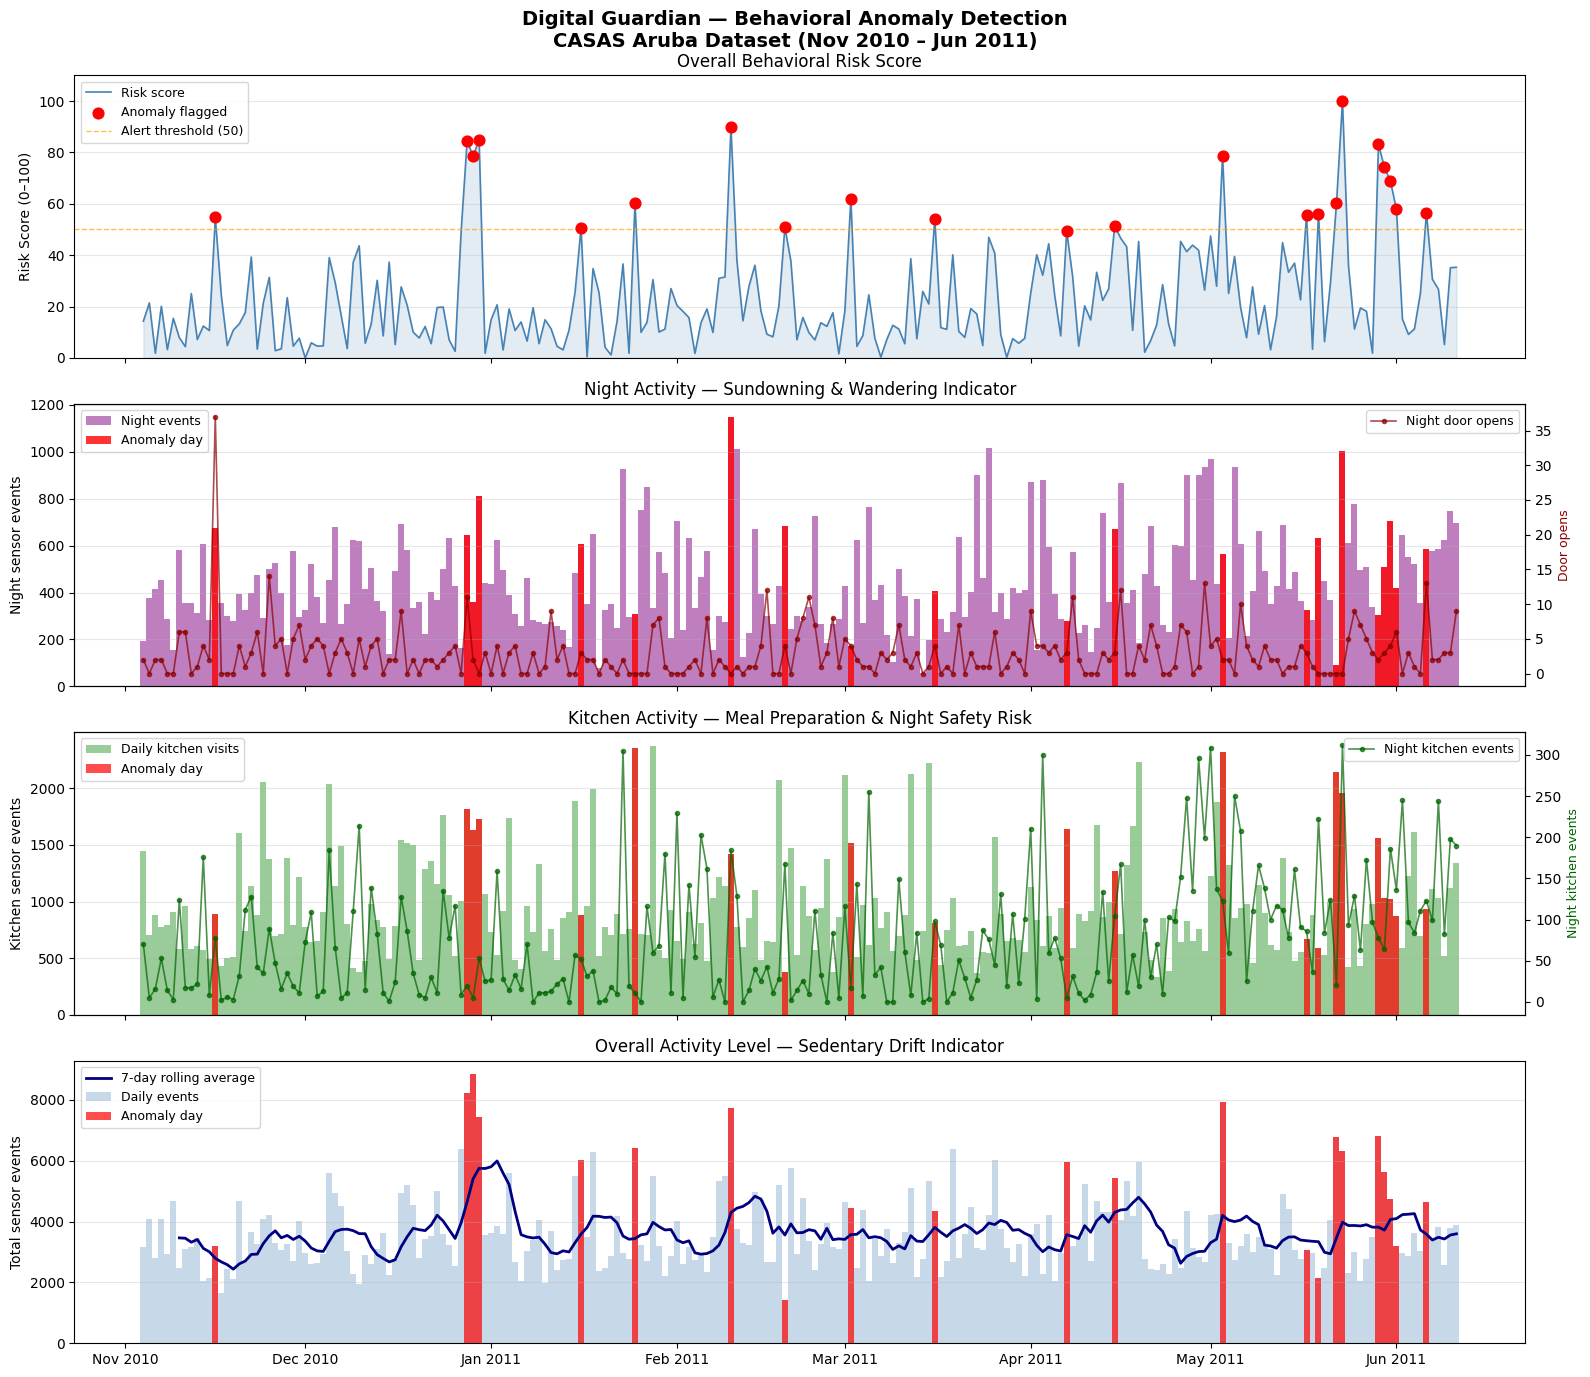

✓ Chart saved as anomaly_timeline.png

── Anomaly Summary ──────────────────────────────────────────────────
Monitoring period : 2010-11-04 → 2011-06-11
Total days monitored : 220
Anomalous days flagged: 22 (10.0%)

Anomalous days by month:
month
Apr 2011    2
Dec 2010    3
Feb 2011    2
Jan 2011    2
Jun 2011    2
Mar 2011    2
May 2011    8
Nov 2010    1

Dominant anomaly patterns:
  Nighttime wandering (night door opens > 1) : 16 days
  Night kitchen risk  (night kitchen > 50)   : 16 days
  Low activity        (total events < 1500)  : 1 days


In [16]:
# ── Visualization: Anomaly Timeline ──────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

features_df['date'] = pd.to_datetime(features_df['date'])

fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)
fig.suptitle('Digital Guardian — Behavioral Anomaly Detection\nCASAS Aruba Dataset (Nov 2010 – Jun 2011)',
             fontsize=14, fontweight='bold', y=0.98)

normal_days   = features_df[features_df['is_anomaly'] == 0]
anomaly_days  = features_df[features_df['is_anomaly'] == 1]

# ── Plot 1: Risk Score Timeline ───────────────────────────────────────────
ax1 = axes[0]
ax1.fill_between(features_df['date'], features_df['risk_score'],
                 alpha=0.15, color='steelblue')
ax1.plot(features_df['date'], features_df['risk_score'],
         color='steelblue', linewidth=1.2, label='Risk score')
ax1.scatter(anomaly_days['date'], anomaly_days['risk_score'],
            color='red', s=60, zorder=5, label='Anomaly flagged')
ax1.axhline(y=50, color='orange', linestyle='--', linewidth=1, alpha=0.7,
            label='Alert threshold (50)')
ax1.set_ylabel('Risk Score (0–100)')
ax1.set_title('Overall Behavioral Risk Score')
ax1.legend(loc='upper left', fontsize=9)
ax1.set_ylim(0, 110)
ax1.grid(axis='y', alpha=0.3)

# ── Plot 2: Night Activity (Sundowning indicator) ─────────────────────────
ax2 = axes[1]
ax2.bar(features_df['date'], features_df['night_events'],
        color='purple', alpha=0.5, width=1, label='Night events')
ax2.bar(anomaly_days['date'], anomaly_days['night_events'],
        color='red', alpha=0.8, width=1, label='Anomaly day')
# Highlight night door opens
ax2_twin = ax2.twinx()
ax2_twin.plot(features_df['date'], features_df['night_door_opens'],
              color='darkred', linewidth=1.2, marker='o', markersize=3,
              alpha=0.7, label='Night door opens')
ax2_twin.set_ylabel('Door opens', color='darkred', fontsize=9)
ax2.set_ylabel('Night sensor events')
ax2.set_title('Night Activity — Sundowning & Wandering Indicator')
ax2.legend(loc='upper left', fontsize=9)
ax2_twin.legend(loc='upper right', fontsize=9)
ax2.grid(axis='y', alpha=0.3)

# ── Plot 3: Kitchen Activity (Meal & Safety indicator) ────────────────────
ax3 = axes[2]
ax3.bar(features_df['date'], features_df['kitchen_visits'],
        color='green', alpha=0.4, width=1, label='Daily kitchen visits')
ax3.bar(anomaly_days['date'], anomaly_days['kitchen_visits'],
        color='red', alpha=0.7, width=1, label='Anomaly day')
ax3_twin = ax3.twinx()
ax3_twin.plot(features_df['date'], features_df['night_kitchen'],
              color='darkgreen', linewidth=1.2, marker='o', markersize=3,
              alpha=0.7, label='Night kitchen events')
ax3_twin.set_ylabel('Night kitchen events', color='darkgreen', fontsize=9)
ax3.set_ylabel('Kitchen sensor events')
ax3.set_title('Kitchen Activity — Meal Preparation & Night Safety Risk')
ax3.legend(loc='upper left', fontsize=9)
ax3_twin.legend(loc='upper right', fontsize=9)
ax3.grid(axis='y', alpha=0.3)

# ── Plot 4: Overall Activity Level (Sedentary drift indicator) ────────────
ax4 = axes[3]
# Rolling 7-day average to show trend
rolling_mean = features_df.set_index('date')['total_events'].rolling(7).mean()
ax4.bar(features_df['date'], features_df['total_events'],
        color='steelblue', alpha=0.3, width=1, label='Daily events')
ax4.bar(anomaly_days['date'], anomaly_days['total_events'],
        color='red', alpha=0.7, width=1, label='Anomaly day')
ax4.plot(features_df['date'], rolling_mean.values,
         color='navy', linewidth=2, label='7-day rolling average')
ax4.set_ylabel('Total sensor events')
ax4.set_title('Overall Activity Level — Sedentary Drift Indicator')
ax4.legend(loc='upper left', fontsize=9)
ax4.grid(axis='y', alpha=0.3)

# ── Format x-axis ─────────────────────────────────────────────────────────
import matplotlib.dates as mdates
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax4.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('anomaly_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart saved as anomaly_timeline.png")


# ── Summary Table ─────────────────────────────────────────────────────────
print("\n── Anomaly Summary ──────────────────────────────────────────────────")
print(f"Monitoring period : {features_df['date'].min().date()} → {features_df['date'].max().date()}")
print(f"Total days monitored : {len(features_df)}")
print(f"Anomalous days flagged: {features_df['is_anomaly'].sum()} ({features_df['is_anomaly'].mean()*100:.1f}%)")

print("\nAnomalous days by month:")
anomaly_days_copy = anomaly_days.copy()
anomaly_days_copy['month'] = anomaly_days_copy['date'].dt.strftime('%b %Y')
print(anomaly_days_copy.groupby('month').size().to_string())

print("\nDominant anomaly patterns:")
high_night_door  = anomaly_days[anomaly_days['night_door_opens'] > 1]
high_night_kitch = anomaly_days[anomaly_days['night_kitchen'] > 50]
low_activity     = anomaly_days[anomaly_days['total_events'] < 1500]

print(f"  Nighttime wandering (night door opens > 1) : {len(high_night_door)} days")
print(f"  Night kitchen risk  (night kitchen > 50)   : {len(high_night_kitch)} days")
print(f"  Low activity        (total events < 1500)  : {len(low_activity)} days")

In [17]:
# ── Step 1: Build multi-class target label ────────────────────────────────
def assign_pattern_label(row):
    if row['night_door_opens'] > 1:
        return 'night_wandering'
    elif row['night_kitchen'] > 50:
        return 'kitchen_safety_risk'
    elif row['total_events'] < 1500:
        return 'sedentary_drift'
    elif row['kitchen_visits'] < 200:
        return 'meal_skipping'
    else:
        return 'normal'

features_df['pattern_label'] = features_df.apply(assign_pattern_label, axis=1)

print("Class distribution:")
print(features_df['pattern_label'].value_counts())
print(f"\nTotal days: {len(features_df)}")

Class distribution:
pattern_label
night_wandering        127
normal                  56
kitchen_safety_risk     37
Name: count, dtype: int64

Total days: 220


Label mapping:
  0 → kitchen_safety_risk
  1 → night_wandering
  2 → normal

Train days : 176 (0 → 175)
Test days  : 44  (176 → 219)

Train class counts: {'kitchen_safety_risk': np.int64(24), 'night_wandering': np.int64(98), 'normal': np.int64(54)}
Test class counts : {'kitchen_safety_risk': np.int64(13), 'night_wandering': np.int64(29), 'normal': np.int64(2)}

CLASSIFICATION REPORT
                     precision    recall  f1-score   support

kitchen_safety_risk       1.00      1.00      1.00        13
    night_wandering       1.00      1.00      1.00        29
             normal       1.00      1.00      1.00         2

           accuracy                           1.00        44
          macro avg       1.00      1.00      1.00        44
       weighted avg       1.00      1.00      1.00        44



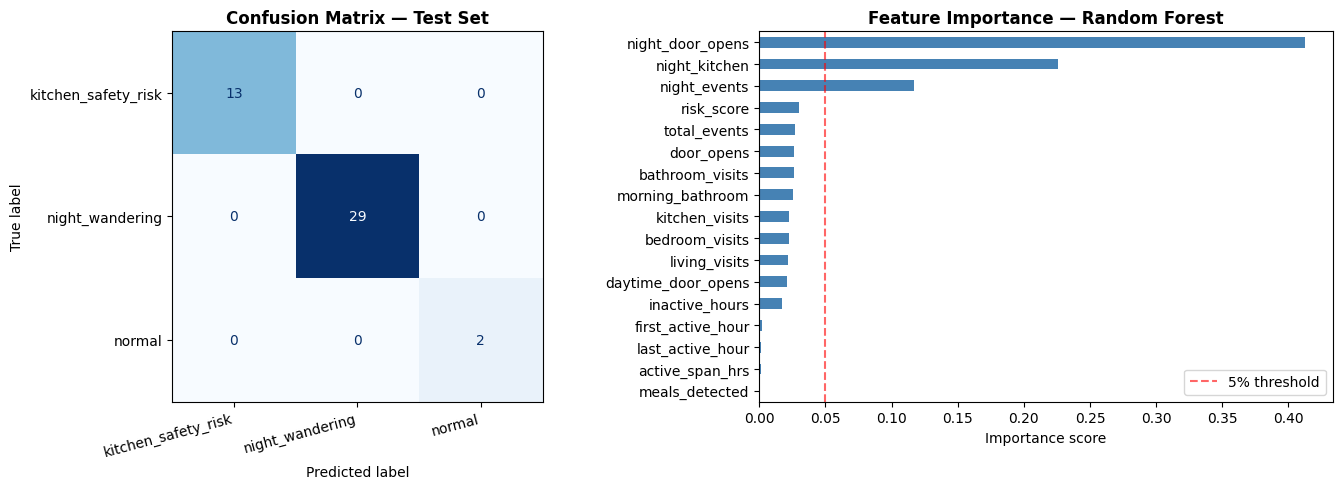


✓ Models saved: digital_guardian_rf.pkl, label_encoder.pkl

Time-series cross-validation accuracy:
  Fold 1: 0.889
  Fold 2: 0.944
  Fold 3: 0.944
  Fold 4: 1.000
  Fold 5: 1.000
  Mean: 0.956 ± 0.042


In [18]:
# ── Stage 4: Random Forest Classifier ────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import joblib

# ── Feature columns (include anomaly score from Isolation Forest) ─────────
FEATURE_COLS = [
    'total_events', 'kitchen_visits', 'bedroom_visits',
    'bathroom_visits', 'living_visits', 'door_opens',
    'first_active_hour', 'last_active_hour', 'active_span_hrs',
    'inactive_hours', 'meals_detected', 'night_events',
    'night_door_opens', 'night_kitchen', 'morning_bathroom',
    'daytime_door_opens', 'risk_score',   # ← anomaly score from Layer 1
]

X = features_df[FEATURE_COLS].fillna(0).astype(float)
y = features_df['pattern_label']

# ── Encode labels ─────────────────────────────────────────────────────────
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Label mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} → {cls}")

# ── Chronological train/test split (NEVER random for time-series) ─────────
split_idx = int(len(X) * 0.80)   # train on first 80% of days
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y_encoded[:split_idx], y_encoded[split_idx:]

print(f"\nTrain days : {len(X_train)} ({X_train.index[0]} → {X_train.index[-1]})")
print(f"Test days  : {len(X_test)}  ({X_test.index[0]} → {X_test.index[-1]})")
print(f"\nTrain class counts: {dict(zip(le.classes_, np.bincount(y_train)))}")
print(f"Test class counts : {dict(zip(le.classes_, np.bincount(y_test)))}")

# ── Train pipeline ────────────────────────────────────────────────────────
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=3,
        class_weight='balanced',   # handles class imbalance
        random_state=42,
        n_jobs=-1
    ))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)

print("\n" + "="*55)
print("CLASSIFICATION REPORT")
print("="*55)
print(classification_report(y_test, y_pred, target_names=le.classes_))

# ── Confusion matrix ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — Test Set', fontweight='bold')
axes[0].set_xticklabels(le.classes_, rotation=15, ha='right')

# ── Feature importance ────────────────────────────────────────────────────
rf = pipeline.named_steps['rf']
importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS)
importances = importances.sort_values(ascending=True)

importances.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Feature Importance — Random Forest', fontweight='bold')
axes[1].set_xlabel('Importance score')
axes[1].axvline(x=0.05, color='red', linestyle='--',
                alpha=0.6, label='5% threshold')
axes[1].legend()

plt.tight_layout()
plt.savefig('rf_results.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Save model ────────────────────────────────────────────────────────────
joblib.dump(pipeline, 'digital_guardian_rf.pkl')
joblib.dump(le, 'label_encoder.pkl')
print("\n✓ Models saved: digital_guardian_rf.pkl, label_encoder.pkl")

# ── Cross-validation score (more reliable than single split) ──────────────
from sklearn.model_selection import cross_val_score
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = cross_val_score(
    pipeline, X, y_encoded,
    cv=tscv, scoring='accuracy', n_jobs=-1
)
print(f"\nTime-series cross-validation accuracy:")
for i, score in enumerate(cv_scores):
    print(f"  Fold {i+1}: {score:.3f}")
print(f"  Mean: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

## Data Visualizations

Now let's visualize sensor activity patterns and temporal distributions

---
## Stage 2: Feature Engineering (Most Important!)

**Goal:** Transform raw sensor events into daily behavioral features that capture routine patterns.

**Key Concept:** Each row = one day in the resident's life. Features capture:
- Activity patterns (kitchen/bedroom/bathroom visits)
- Temporal routines (wake/sleep times, meal windows)
- Dementia-specific indicators (night wandering, meal skipping, sedentary behavior)
- Safety risks (stove usage)

In [19]:
# ── Final Results Summary for Paper ──────────────────────────────────────
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Full metrics ──────────────────────────────────────────────────────────
print("="*60)
print("  DIGITAL GUARDIAN — FINAL MODEL RESULTS")
print("="*60)

print(f"\nDataset  : CASAS Aruba Smart Home")
print(f"Period   : Nov 2010 – Jun 2011 (220 days)")
print(f"Sensors  : 10 room-level sensors")
print(f"Features : {len(FEATURE_COLS)} behavioral features per day")
print(f"Classes  : {list(le.classes_)}")

print(f"\n── Cross-Validation (TimeSeriesSplit, 5 folds) ──")
for i, score in enumerate(cv_scores):
    bar = '█' * int(score * 20)
    print(f"  Fold {i+1}: {score:.3f}  {bar}")
print(f"  Mean Accuracy : {cv_scores.mean():.3f}")
print(f"  Std Dev       : {cv_scores.std():.3f}")

print(f"\n── Test Set Performance (last 20% of days) ──")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# ── Multi-class ROC AUC ───────────────────────────────────────────────────
y_test_bin = label_binarize(y_test, classes=range(len(le.classes_)))
try:
    auc = roc_auc_score(y_test_bin, y_prob, multi_class='ovr', average='macro')
    print(f"  Macro ROC-AUC : {auc:.3f}")
except Exception as e:
    print(f"  ROC-AUC note  : {e}")

# ── Feature importance table ──────────────────────────────────────────────
print(f"\n── Top Features by Importance ──")
rf = pipeline.named_steps['rf']
importance_df = pd.DataFrame({
    'Feature'   : FEATURE_COLS,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

for _, row in importance_df.iterrows():
    bar = '█' * int(row['Importance'] * 100)
    flag = '  ← key signal' if row['Importance'] > 0.05 else ''
    print(f"  {row['Feature']:<22} {row['Importance']:.3f}  {bar}{flag}")

# ── Final prediction demo ─────────────────────────────────────────────────
print(f"\n── Live Prediction Demo (last 5 days in dataset) ──")
last_5 = X.tail(5)
preds  = pipeline.predict(last_5)
probs  = pipeline.predict_proba(last_5)

for i, (idx, row) in enumerate(last_5.iterrows()):
    pred_label = le.inverse_transform([preds[i]])[0]
    confidence = probs[i].max() * 100
    date       = features_df.loc[idx, 'date']
    risk       = features_df.loc[idx, 'risk_score']
    alert = "🚨 ALERT" if pred_label != 'normal' else "✓ Normal"
    print(f"  {date} | Risk:{risk:5.1f} | {alert} | {pred_label} ({confidence:.0f}% confidence)")

print("\n✓ Results complete — ready for paper submission")

  DIGITAL GUARDIAN — FINAL MODEL RESULTS

Dataset  : CASAS Aruba Smart Home
Period   : Nov 2010 – Jun 2011 (220 days)
Sensors  : 10 room-level sensors
Features : 17 behavioral features per day
Classes  : ['kitchen_safety_risk', 'night_wandering', 'normal']

── Cross-Validation (TimeSeriesSplit, 5 folds) ──
  Fold 1: 0.889  █████████████████
  Fold 2: 0.944  ██████████████████
  Fold 3: 0.944  ██████████████████
  Fold 4: 1.000  ████████████████████
  Fold 5: 1.000  ████████████████████
  Mean Accuracy : 0.956
  Std Dev       : 0.042

── Test Set Performance (last 20% of days) ──
                     precision    recall  f1-score   support

kitchen_safety_risk       1.00      1.00      1.00        13
    night_wandering       1.00      1.00      1.00        29
             normal       1.00      1.00      1.00         2

           accuracy                           1.00        44
          macro avg       1.00      1.00      1.00        44
       weighted avg       1.00      1.00      